## Imoporting Necessary Libraries

In [48]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import pickle 
import spacy

## Data processing to remove inconcistencies in the text data

In [49]:
class TextProcessing:
    def __init__(self, review):
        self.review=review
    def processing(self):
        with open(self.review, 'r', newline='') as f:
            reader = csv.DictReader(f)
            with open('data.csv', 'w', newline='') as out_f:
                fieldnames = ['Country', 'Review Date', 'Review Title', 'Review Text', 'Rating']  
                writer = csv.DictWriter(out_f, fieldnames=fieldnames)
                writer.writeheader()
                for row in reader:
                    writer.writerow({
                        'Country': row['Country'],
                        'Review Date': row['Review Date'],
                        'Review Title': row['Review Title'],
                        'Review Text' : row['Review Text'],
                        'Rating': row['Rating']
                })
        df = pd.read_csv('data.csv', parse_dates=['Review Date'],on_bad_lines='skip')
        df.dropna(inplace=True)
        df.drop_duplicates(inplace=True)
        #df['Rating'].str.split()
        df['Num_Rating']=df['Rating'].apply(lambda x:'POSITIVE' if int(x[6])>=4 else 'NEUTRAL' if int(x[6])==3 else 'NEGATIVE') #if int(x)<3)
        df['Review Date']= df['Review Date'].dt.year
        return df
    def Graph(self):
        df=self.processing()
        fg=df[df['Review Date']>2015]
        df.head()
        df['Num_Rating'].value_counts().plot(kind='bar', color='g')
        df[['Review Date','Num_Rating']] .value_counts()

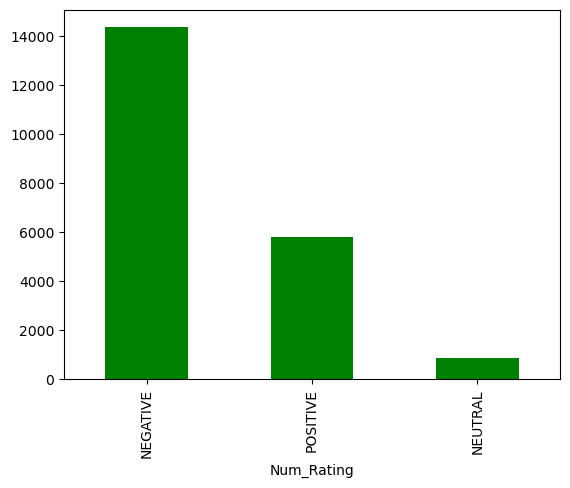

In [52]:
data_ = TextProcessing('Amazon_Reviews.csv')
data_.Graph()

## Feature Extraction

In [51]:
data=data_.processing()
data['num_rate']=data['Num_Rating'].map({'POSITIVE':'Positive', 'NEUTRAL':'Negative','NEGATIVE':'Negative'})
print(data['Review Text'].str.len().sum())

9702587


In [ ]:
!pip install -U spacy
!python -m spacy download en_core_web_sm

In [6]:
nlp=spacy.load('en_core_web_sm') # Function to clean and process the data for training
def lemma(text):
    doc=nlp(''.join(text))
    tok=[token.lemma_ for token in doc if not token.is_punct and not token.is_stop]
    return ' '.join(tok)

In [53]:
#data['text_xtract']=data['Review Text'].apply(lemma)
X,y= data['Review Text'].values ,data['num_rate'].values
Xtrain, Xtest,ytrain,ytest = train_test_split(X, y, test_size=0.05,random_state=42, shuffle=True)
ytrain[:100].dtype

dtype('O')

In [54]:
print(data['Review Text'].str.len().sum())
data.num_rate.value_counts(normalize=True)  #Checking to see how unbalanced is the dataset

9702587


num_rate
Negative    0.723615
Positive    0.276385
Name: proportion, dtype: float64

## Model Train

In [ ]:
#Model train
pipe=Pipeline([('scalar', TfidfVectorizer()), ('clf', RandomForestClassifier())])

param_grid= [
            {'clf': [KNeighborsClassifier()]},
            {'clf': [SVC()]},
            {'clf': [RandomForestClassifier()]}
            ]
grid= GridSearchCV(estimator=pipe, 
                   param_grid=param_grid,           
                   cv=5,
                   scoring= make_scorer(f1_score, average='macro'),
                   refit = True
                      )
#grid.fit(Xtrain, ytrain)

In [5]:
pipe=Pipeline([('transformer',TfidfVectorizer()),
               ('model', LinearSVC())
              ]
             )
params = [
    {
        'model': [LinearSVC()],
        'model__C': np.linspace(0.5, 2, 6),
        'model__class_weight': [{'Negative': 1, 'Positive': v} for v in range(1, 6)]
    },
    {
        'model': [LogisticRegression(max_iter=1000)],
        'model__C': np.linspace(0.5, 2, 6),
        'model__class_weight': [{'Nehative': 1, 'Negative': v} for v in range(1, 6)]
    }
    ]
grid= GridSearchCV(pipe,
                 param_grid=params,
                 cv=5,
                 #scoring='f1',
                 refit=True
                 )

In [21]:
mod= grid.fit(Xtrain, ytrain)

In [22]:
print(f' best training score: {mod.best_score_},\n best parameters: {mod.best_params_}')
mod.best_estimator_

 best training score: 0.9218039240189952,
 best parameters: {'model': LogisticRegression(max_iter=1000), 'model__C': np.float64(2.0), 'model__class_weight': {0: 1, 1: 2}}


,steps,"[('transformer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


## Model Evaluation

In [24]:
y_pred=grid.predict(Xtest)
score=f1_score(y_pred, ytest)
score

0.8486956521739131

<Figure size 500x500 with 0 Axes>

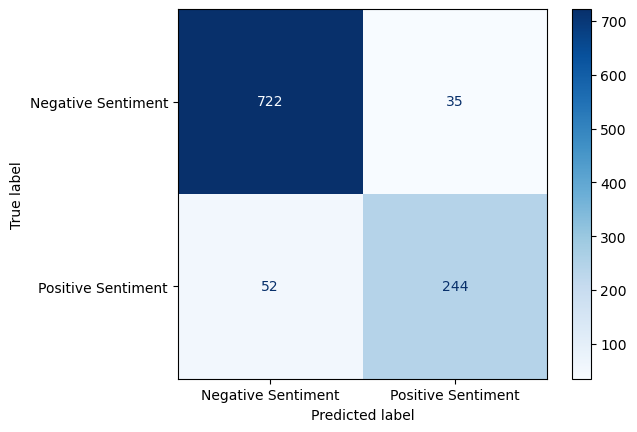

In [29]:
cm=confusion_matrix(y_pred, ytest)
disp=ConfusionMatrixDisplay(cm, display_labels=["Negative Sentiment","Positive Sentiment"])
plt.figure(figsize=(5,5))
disp.plot(cmap=plt.cm.Blues)
plt.show()

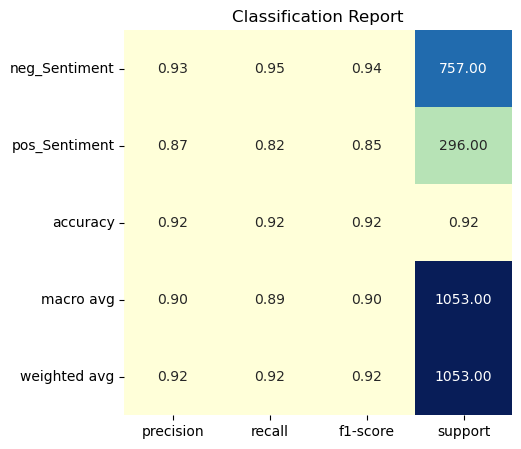

In [27]:
output=classification_report(y_pred, ytest ,output_dict=True )
to_frame=pd.DataFrame(output).transpose()
to_frame.index=['neg_Sentiment', 'pos_Sentiment', 'accuracy', 'macro avg', 'weighted avg']
plt.figure(figsize=(5,5))
sns.heatmap(to_frame,annot=True,
            cmap='YlGnBu',fmt='.2f',cbar=False)
plt.title('Classification Report')
plt.show()

In [15]:
y=lambda x: 'Postive Sentiment' if mod.predict(x)==1.0 else 'Negative Sentiment'

In [17]:
y([r"i cannotrecommend this"])
#mod.predict([r"i can not recommend this"])

'Negative Sentiment'

## Model Deployment

In [59]:
with open('fitted', 'wb') as model:
    pickle.dump(mod, model)


def prediction(text):
    with open('fitted', 'rb') as model:
        model=pickle.load(model)
        print('Positive Sentiment') if model.best_estimator_.predict(text)==1 else print('Negative Sentiment') 

In [ ]:
pipe=[Pipeline([('scaler',TfidfVectorizer()),
      ('model', KNeighborsClassifier())]),
      Pipeline([('scaler', TfidfVectorizer()),
      ('model', SVC())]),
      Pipeline([('scaler', CountVectorizer()),
      ('model', RandomForestClassifier())])
      ]
param_grid= [
             {'model__n_neighbors': np.arange(5,20)},
             {'model__class_weight': [{0:1, 1:v} for v in range(1,10)]},
             {'model__max_depth': np.arange(10)}
            ]

for i in zip(pipe, param_grid):
  mod=GridSearchCV(estimator=i[0], param_grid=i[1], cv=5)
  mod.fit(Xtrain, ytrain)
  print(mod.best_params_)
  print(i[0], i[1])

In [24]:
mod.best_estimator_

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [43]:
yt=mod.predict(Xtest)
score=accuracy_score(yt, ytest)
score

0.731718898385565

In [ ]:
mod.

### Model Deployment

In [66]:
with open('model.pkl', 'wb') as f:
    pickle.dump(grid, f)

In [84]:
with open('model.pkl', 'rb') as f:
    model=pickle.load(f)
    y=lambda x: 'Postive Sentiment' if model.predict(x)==1 else 'Negative Sentiment'
    print(y(['not good value for my money']))

Negative Sentiment


In [20]:
voting = VotingClassifier(
    estimators=[
        ('lr', Pipeline([
            ('scaler', CountVectorizer()),
            ('lr', LogisticRegression())
        ])),

        ('svc', Pipeline([
            ('scaler', CountVectorizer()),
            ('svc', SVC())
        ])),

        ('dt', Pipeline([
            ('scaler', CountVectorizer()),
            ('dt', DecisionTreeClassifier())
        ])),

        ('knn', Pipeline([
            ('scaler', CountVectorizer()),
            ('knn', KNeighborsClassifier())
        ]))
    ],
    voting='soft')
#voting.fit(Xtrain, ytrain.ravel())
#y_pred = voting.predict(Xtest)
#print(confusion_matrix(ytest.ravel(), y_pred))
#print(classification_report(ytest.ravel(), y_pred))

In [63]:
Xtrain2, Xtest2,ytrain2,ytest2 = train_test_split(X, 
                                                  y, test_size=0.05,
                                                  random_state=42, 
                                                  shuffle=True)

In [64]:
import joblib
import os

TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=60_000,
    sublinear_tf=True
)

pipe2 = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )),
    ("model", "placeholder")
])

params = [
    {
        'model': [LinearSVC()],
        'model__C': np.linspace(0.5, 2, 6),
        'model__class_weight': [{'Negative': 1, 'Positive': v} for v in range(1, 5)]
    },
    {
        'model': [LogisticRegression(max_iter=1000)],
        'model__C': np.linspace(0.5, 2, 6),
        'model__class_weight': [{'Negative': 1, 'Positive': v} for v in range(1, 5)]
    }
    ]

model_2= GridSearchCV(pipe2,
                 param_grid=params,
                 cv=5,
                scoring=f1_score,
                refit=True
                 )

In [65]:
model_2.fit(Xtrain2, ytrain2)

/Users/imohekpenyong/anaconda3/envs/end2end/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/imohekpenyong/anaconda3/envs/end2end/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/Users/imohekpenyong/anaconda3/envs/end2end/lib/python3.14/site-packages/sklearn/utils/_param_validation.py", line 196, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "/Users/imohekpenyong/anaconda3/envs/end2end/lib/python3.14/inspect.py", line 3236, in bind
    return self._bind(args, kwargs)
           ~~~~~~~~~~^^^^^^^^^^^^^^
  File "/Users/imohekpenyong/anaconda3/envs/end2end/lib/python3.14/inspect.py", line 3160, in _bind
    raise TypeError(
        'too many positional arguments') from Non

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...laceholder')])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model': [LinearSVC()], 'model__C': array([0.5, 0....4, 1.7, 2. ]), 'model__class_weight': [{'Negative': 1, 'Positive': 1}, {'Negative': 1, 'Positive': 2}, ...]}, {'model': [LogisticRegre...max_iter=1000)], 'model__C': array([0.5, 0....4, 1.7, 2. ]), 'model__class_weight': [{'Negative': 1, 'Positive': 1}, {'Negative': 1, 'Positive': 2}, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",<function f1_...t 0x16a806350>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation 

In [66]:
model_2.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [67]:
model_2.best_estimator_.score(Xtest2, ytest2)

0.9211775878442545

In [68]:
#os.makedirs("models", exist_ok=True)
import os

path = os.path.join(os.path.dirname(os.getcwd()), "models")
joblib.dump(model_2.best_estimator_, f'{path}/sentiment_model.joblib')

['/Users/imohekpenyong/sentiment_analysis/models/sentiment_model.joblib']

In [32]:
import os

path = os.path.join(os.path.dirname(os.getcwd()), "models")
print(path)
print(os.path.exists(path))

/Users/imohekpenyong/sentiment_analysis/models
True


In [70]:
model_2.best_estimator_.predict(['love this product'])

array(['Positive'], dtype=object)